In [5]:
import pandas as pd

df = pd.read_csv("../data/processed/btc_1sec_core.csv")
df['system_time'] = pd.to_datetime(df['system_time'])

### 1. Order Flow Imbalance (OFI)

In [6]:
# simple OFI
df['OFI'] = df['buys'] - df['sells']
df['nOFI'] = df['OFI'] / (df['buys'] + df['sells'] + 1)

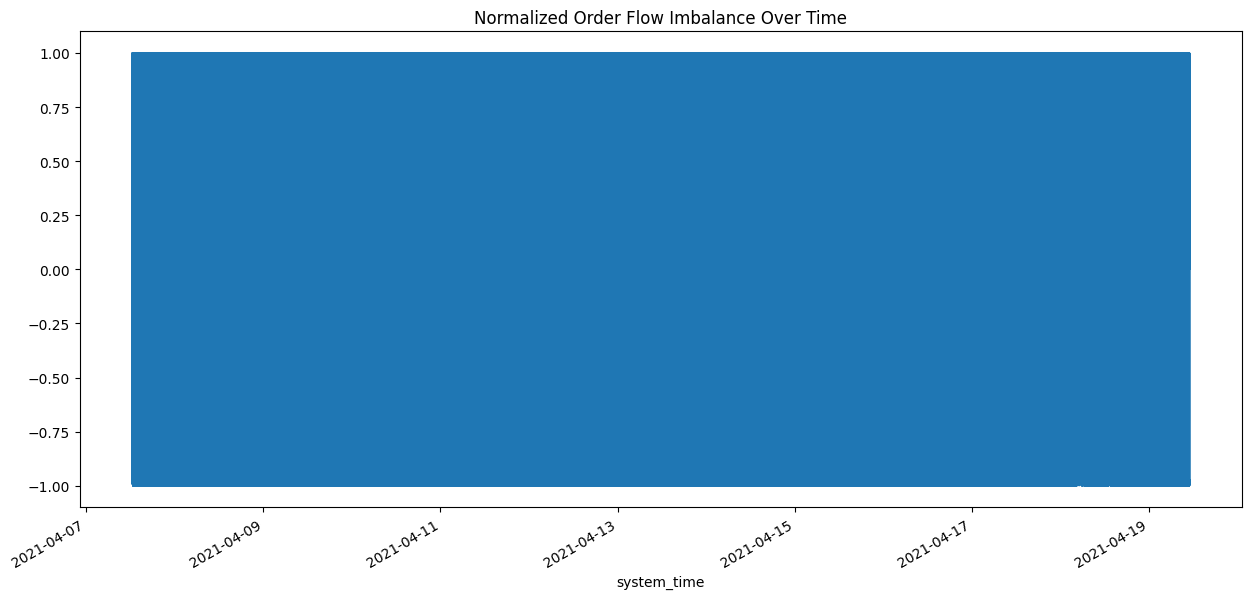

In [11]:
import matplotlib.pyplot as plt
df.set_index('system_time')['nOFI'].plot(figsize=(15,7))
plt.title("Normalized Order Flow Imbalance Over Time")
plt.show()


### 2. Normalized OFI (nOFI) 

In [12]:
df['return_1s'] = df['midpoint'].pct_change()
df[['nOFI', 'return_1s']].corr()

,nOFI,return_1s
nOFI,1.000000,0.216302
return_1s,0.216302,1.000000


#### Downsample

/var/folders/x8/gm81zq055x17w1fwg7l4_q0w0000gn/T/ipykernel_1751/480500795.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_1min = df.set_index('system_time').resample('1T').mean()


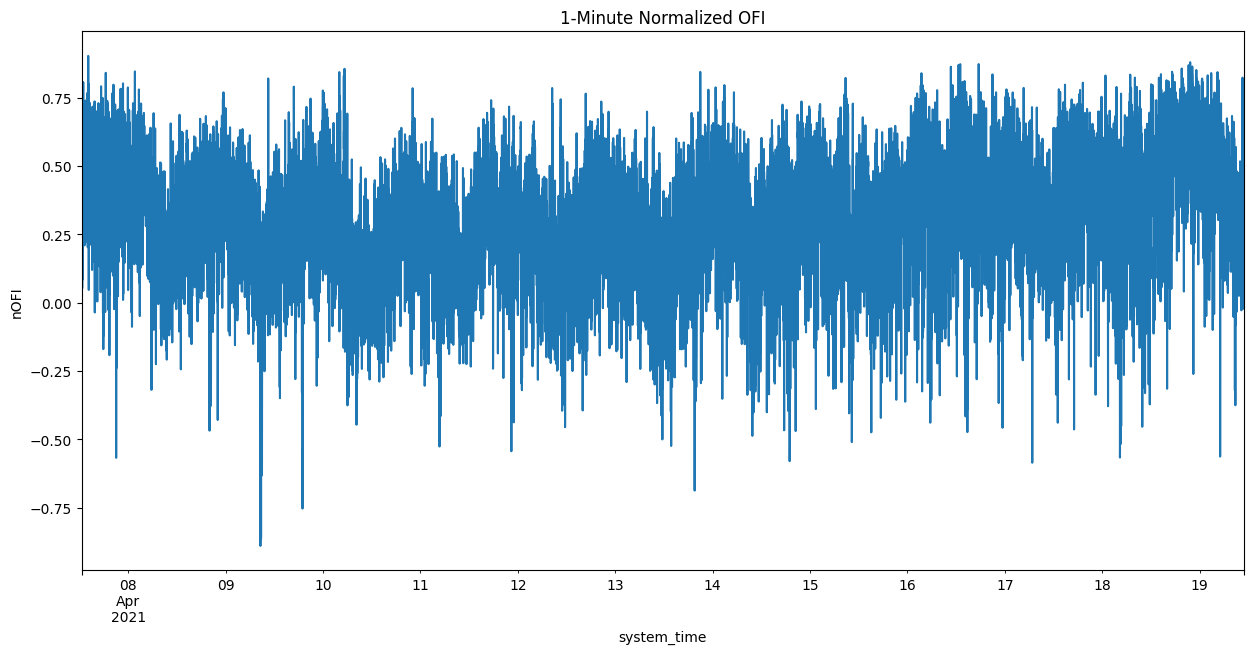

In [14]:
df_1min = df.set_index('system_time').resample('1T').mean()
plt.figure(figsize=(15,7))
df_1min['nOFI'].plot()
plt.title('1-Minute Normalized OFI')
plt.ylabel('nOFI')
plt.show()

#### Zoom in Specific Hour

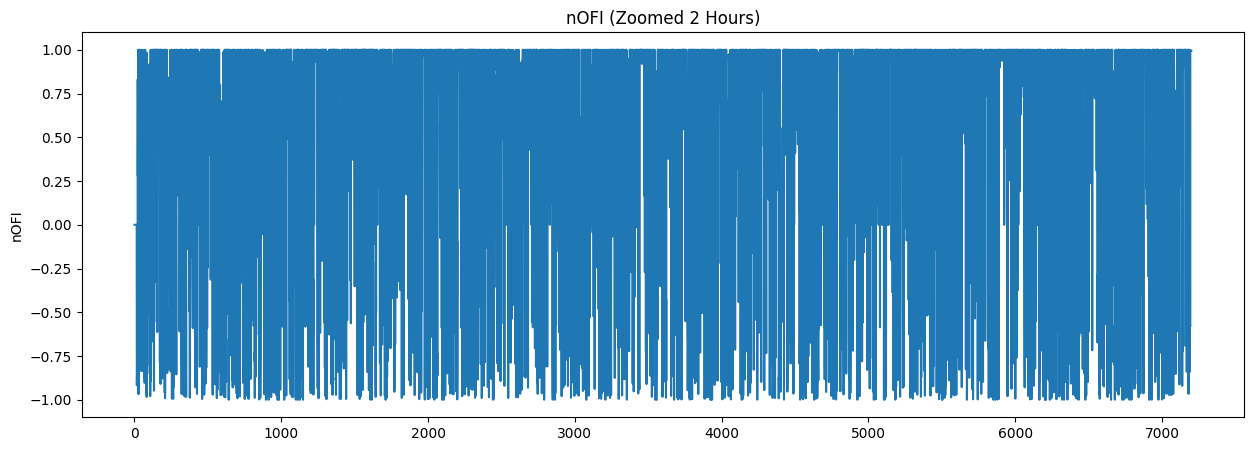

In [16]:
start = df['system_time'].min()
end = start + pd.Timedelta(hours=2)

df_zoom = df[(df['system_time'] >= start) & (df['system_time'] <= end)]

plt.figure(figsize=(15,5))
df_zoom['nOFI'].plot()
plt.title("nOFI (Zoomed 2 Hours)")
plt.ylabel("nOFI")
plt.show()

#### Overlay midpoint price & OFI

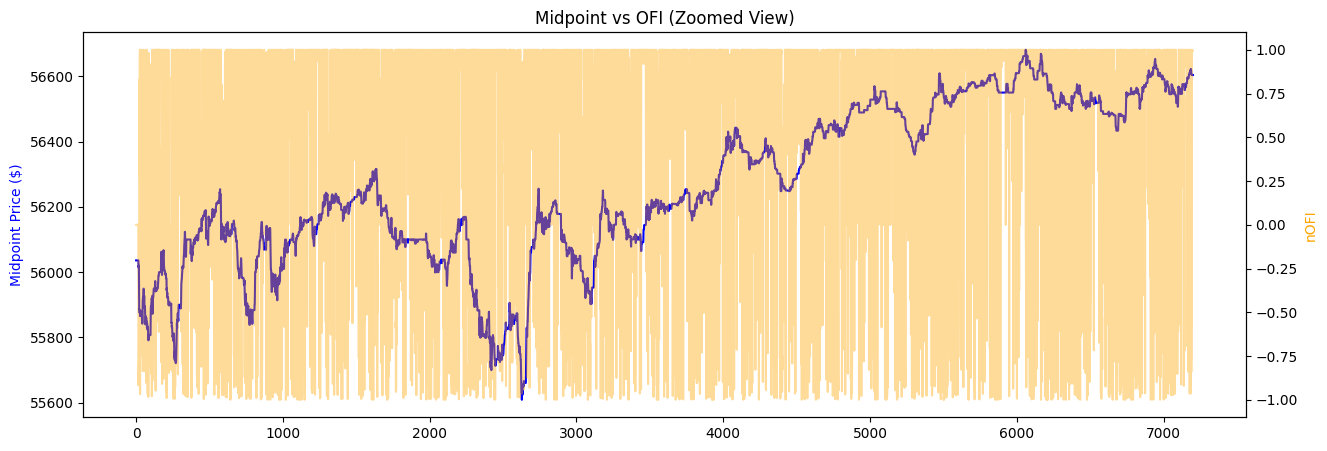

In [17]:
fig, ax1 = plt.subplots(figsize=(15,5))

ax1.plot(df_zoom['midpoint'], color='blue', label='Midpoint')
ax1.set_ylabel("Midpoint Price ($)", color="blue")

ax2 = ax1.twinx()
ax2.plot(df_zoom['nOFI'], color='orange', alpha=0.4, label='nOFI')
ax2.set_ylabel("nOFI", color="orange")

plt.title("Midpoint vs OFI (Zoomed View)")
plt.show()

### 3. Short-Term Volatility

In [18]:
# 60-second realized volatility
df['ret_1s'] = df['midpoint'].pct_change()

df['vol_60s'] = df['ret_1s'].rolling(60).std() * (60**0.5)
df[['ret_1s', 'vol_60s']].head()


,ret_1s,vol_60s
0,NaN,NaN
1,0.0,NaN
2,0.0,NaN
3,0.0,NaN
4,0.0,NaN


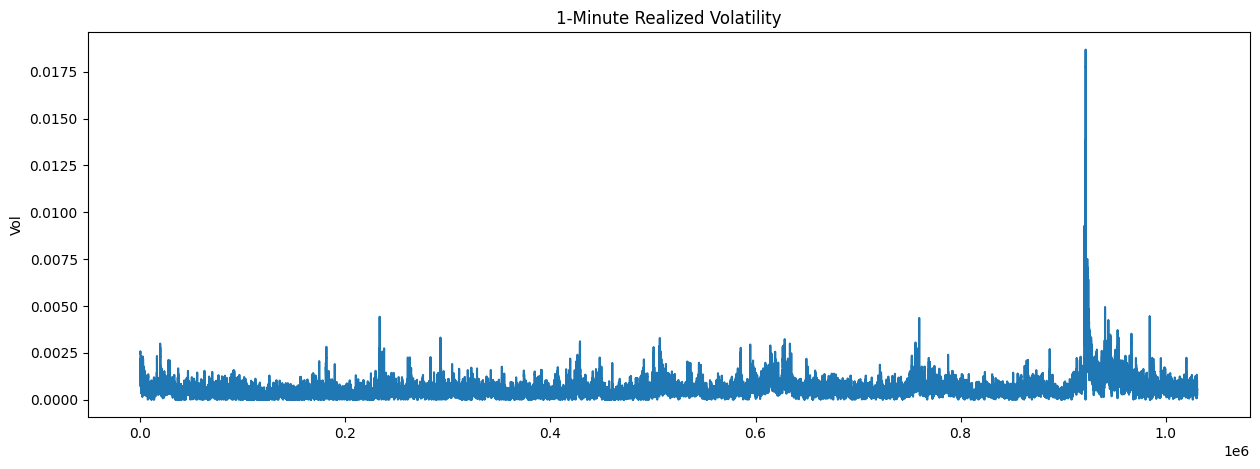

In [19]:
plt.figure(figsize=(15,5))
df['vol_60s'].plot()
plt.title("1-Minute Realized Volatility")
plt.ylabel("Vol")
plt.show()


In [20]:
# Volatility regimes based on quantiles
df['vol_regime'] = pd.qcut(
    df['vol_60s'],
    q=3,
    labels=['Low Vol', 'Medium Vol', 'High Vol']
)


In [21]:
df['ofi_regime'] = pd.cut(
    df['nOFI'],
    bins=[-1, -0.3, 0.3, 1],
    labels=['Sell Pressure', 'Neutral', 'Buy Pressure']
)


In [22]:
regime_stats = (
    df
    .groupby(['vol_regime', 'ofi_regime'])['spread']
    .mean()
    .unstack()
)

regime_stats


/var/folders/x8/gm81zq055x17w1fwg7l4_q0w0000gn/T/ipykernel_1751/3793654630.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['vol_regime', 'ofi_regime'])['spread']


ofi_regime,Sell Pressure,Neutral,Buy Pressure
vol_regime,,,
Low Vol,0.725198,0.465835,0.517133
Medium Vol,1.233752,0.740271,0.887853
High Vol,2.994262,2.121152,2.312791
